Итак, что у нас есть?  

В постановке задачи сказано, что нам предоставлена **выборка** $X_1, X_2, ... , X_n$ из некоторого непрерывного распределения.   

То есть у нас есть упорядоченное множество одинаково распределенных непрерывных независимых случайных величин.

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

Для удобства я переименую свой файл, используя латинские символы.  

И посмотрю вообще на размеры файла, с которым предстоит работать.

In [2]:
source = Path("Levashov_Maksim.xlsx")

df = pd.read_excel(source)

df.shape

(1000000, 2)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 2 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   Unnamed: 0  1000000 non-null  int64  
 1   Выборка     1000000 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 15.3 MB


In [4]:
df.describe()

,Unnamed: 0,Выборка
count,1000000.000000,1000000.000000
mean,499999.500000,1.297595
std,288675.278932,1.296622
min,0.000000,0.000001
25%,249999.750000,0.374431
50%,499999.500000,0.899025
75%,749999.250000,1.798831
max,999999.000000,16.510099


Максимальное значение, которое принимает случайная величина из нашей выбоки - это $\approx$ 16, а минимальная - практически около 0.  Воспользуемся этой информацией, когда будем строить эмпирическую функцию распределния.

### 1. Понять, из какого распределения дана выборка.

У нас есть выборка $X_1, ..., X_n$ объема n, положим, что она извлечена из распределения $\mathcal{F}_{\theta}$, где параметр $\theta \in \Theta \subseteq \mathbb{R}$.  

Хотим узнать, что это за класс распределений $\mathcal{F}$, зависящий от параметра $\theta$?

Первым шагом мы построим гистограмму выборки. Для этого нам будет достаточно встроенного метода hist с параметром bins = "fd" ("Freedman-Diaconis")

Text(0.5, 1.0, 'Гистограмма распределения')

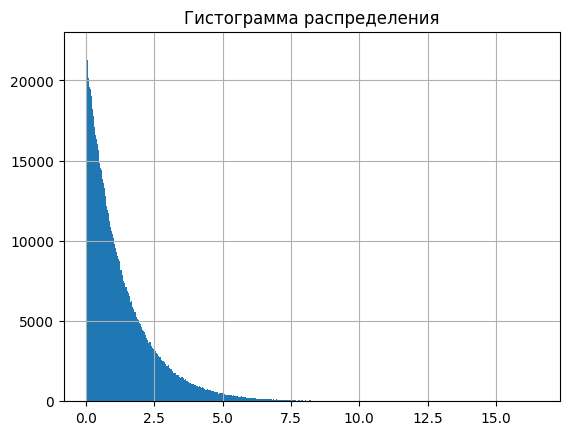

In [5]:
sample = df["Выборка"]
sample.hist(bins="fd")
plt.title("Гистограмма распределения")

И нормализуем значения через параметр Density.

Text(0.5, 1.0, 'Гистограмма распределения (нормализованная)')

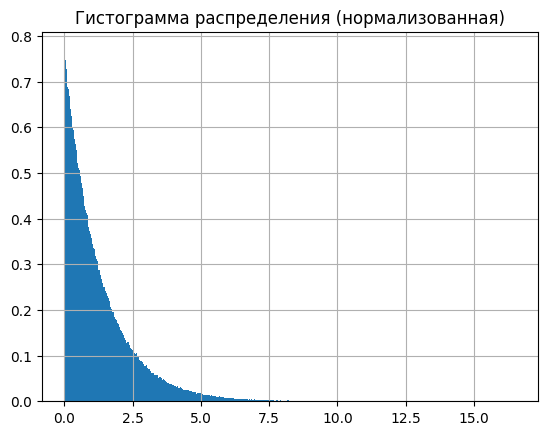

In [6]:
sample = df["Выборка"]
sample.hist(bins="fd", density=True)
plt.title("Гистограмма распределения (нормализованная)")

Вспомним, что такое эмпирическая функция распределения:  
$$F^{*}_n(y) = \frac{1}{n} \sum_{i = 1}^{n} \mathbb{I}(X_i < y)$$
где $$\mathbb{I}(X_i < y) = \begin{cases} 1, если \ X_i < y \\ 0, иначе \end{cases}$$

In [7]:
def I(x, y):
    return int((x < y))

In [8]:
def F(sample: np.ndarray, y) -> float:
    n = len(sample)
    indicators_list = [I(x, y) for x in sample]
    return (1/n) * sum(indicators_list)

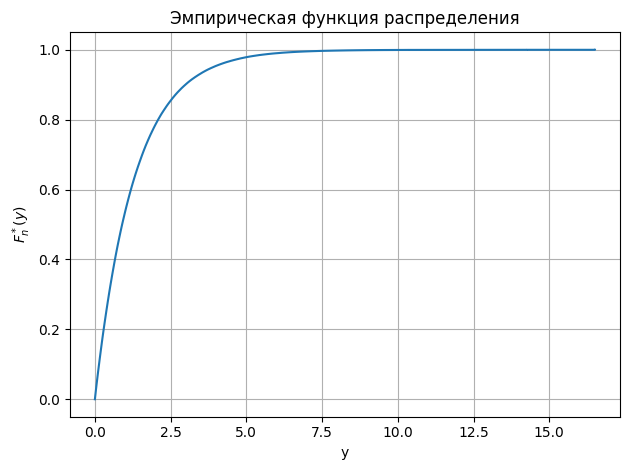

In [9]:
sample_sorted = np.sort(sample)
n = len(sample_sorted)
y_values = np.arange(0, n) / n

plt.step(sample_sorted, y_values, where="post")
plt.title("Эмпирическая функция распределения")
plt.xlabel(rf"y")
plt.ylabel(rf"$F^{'*'}_n(y)$")
plt.grid()
plt.tight_layout()
plt.show()

Оказывается, что ЭФР можно построить через библиотеку statsmodels, посмотрим, насколько наше приближени совпадает:

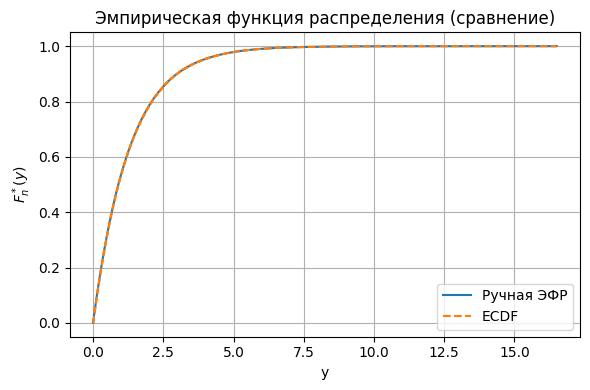

In [10]:
from statsmodels.distributions.empirical_distribution import ECDF

ecdf = ECDF(sample)

x_vals = np.linspace(sample.min(), sample.max(), 1000)
y_ecdf = ecdf(x_vals)

plt.figure(figsize=(6, 4))

plt.step(sample_sorted, y_values, where="post", label="Ручная ЭФР")

plt.step(x_vals, y_ecdf, where="post", label="ECDF", linestyle="--")

plt.title("Эмпирическая функция распределения (сравнение)")
plt.xlabel("y")
plt.ylabel(r"$F_n^*(y)$")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

Выведем теперь оба графика (ЭФР и гистограмма) одновременно.

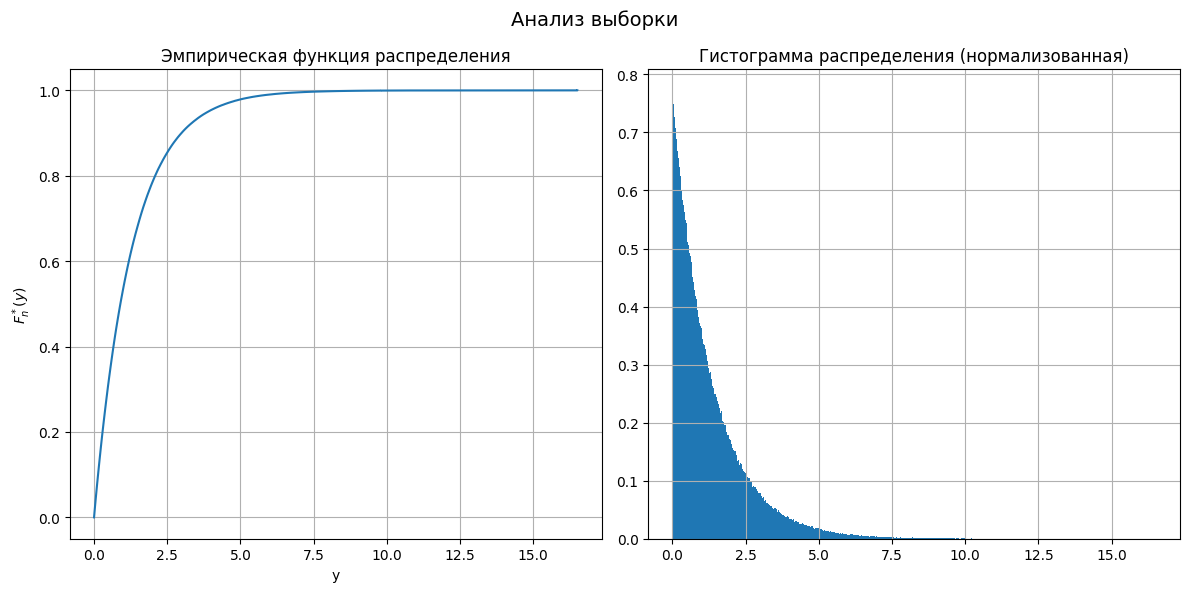

In [11]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,6))
axes = axes.flatten()

fig.suptitle("Анализ выборки", fontsize=14)

sample_sorted = np.sort(sample)
n = len(sample_sorted)
y_values = np.arange(0, n) / n

axes[0].step(sample_sorted, y_values, where="post")
axes[0].set_title("Эмпирическая функция распределения")
axes[0].set_xlabel(rf"y")
axes[0].set_ylabel(rf"$F^{'*'}_n(y)$")
axes[0].grid()

sample = df["Выборка"]
axes[1].hist(sample, bins="fd", density=True)
axes[1].set_title("Гистограмма распределения (нормализованная)")
axes[1].grid()
axes[0].set_xlabel(rf"y")

plt.tight_layout()
plt.show()

Внешне наша ЭФР и гистограмма очень сильно напоминают экспоненциальное распределение.  

Посмотрите сами: говорим, что $\xi \sim E_{\lambda}, \lambda > 0$, если $$f(t) = \begin{cases} \lambda \cdot e^{-\lambda \cdot t}, t > 0 \\ 0, иначе \end{cases}$$

И $$F_{\xi}(t) = \begin{cases} 0, t \leq 0 \\ 1 - e^{-\lambda \cdot t} = 1 - \frac{1}{e^{\lambda \cdot t}}, t > 0 \end{cases}$$

Соответственно (давайте посмотрим на график ЭФР) - в точке **0** у нас значение **0**, а затем мы отнимаем от единицы **много**, после чего, двигаясь по числовой прямой, отнимаем все **меньше**, **приближаясь к единице.**. Именно это  
 нам и говорит запись $1 - e^{-\lambda \cdot t}, t > 0$.  

 С плотностью можно провести аналогичные **"наивные"** рассуждения.

Вроде бы опредилились, что имеем дело с экспоненциальным распределением, допустим, но с каким же параметром? Давайте подумаем:  

Известно, что для экспоненциального распределения $\xi \sim E_{\lambda}$ верно: $\mathbb{E}(\xi) = \frac{1}{\lambda}$.  
И вот допустим, что наша выборка действительно - продукт случайной величины с экспоненциальным распределением $X \sim E_{\lambda}.$ Тогда $$\begin{cases} \overline{X} = \frac{1}{n} \sum X_i \\ \mathbb{E}(X) = \frac{1}{\lambda} \\ \overline{X} \approx \mathbb{E}(X) \end{cases} \Longrightarrow \lambda = \frac{1}{\overline{X}}$$

Давайте проверим это, построив поверх наших графиков аналогичные графики для экспоненциального распределения $\xi \sim E_{\lambda}, \lambda = \frac{1}{\overline{X}}$

lambda = 0.7706567777673368


c:\Users\Cyber Kanojo\Desktop\programming\Mathematical_statistics\Mathematical_statistics\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


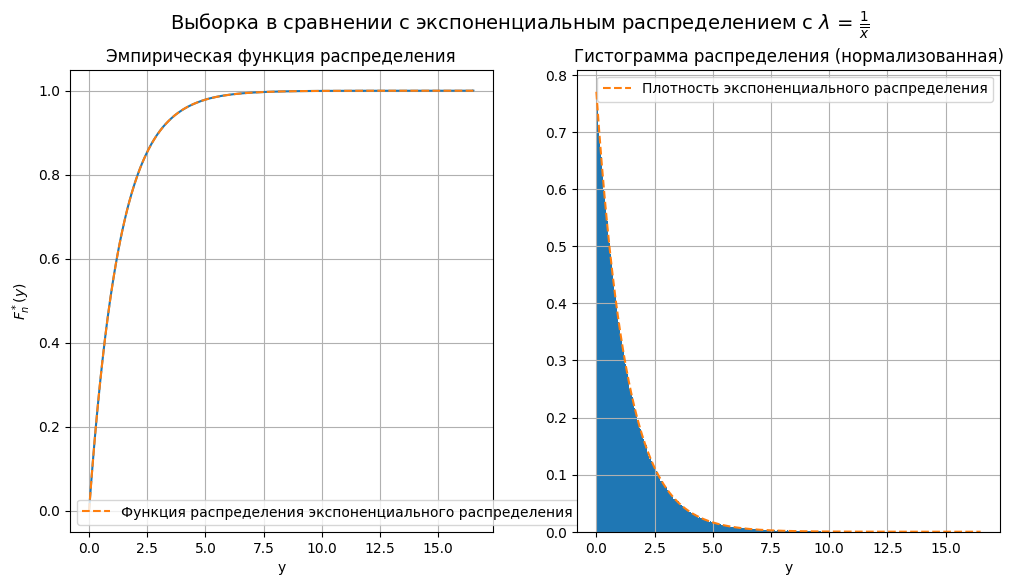

In [12]:
from scipy.stats import expon


loc, scale = expon.fit(sample, floc=0)

lambda_hat = 1 / scale

print(f"lambda = {lambda_hat}")

x = np.linspace(0, max(sample), 1000)

pdf = expon.pdf(x, loc=loc, scale=scale)
cdf = expon.cdf(x, loc=loc, scale=scale)


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,6))
axes = axes.flatten()

fig.suptitle(r"Выборка в сравнении с экспоненциальным распределением с $\lambda$ = $\frac{1}{\overline{x}}$", fontsize=14)

sample_sorted = np.sort(sample)
n = len(sample_sorted)
y_values = np.arange(0, n) / n

axes[0].step(sample_sorted, y_values, where="post")
axes[0].set_title("Эмпирическая функция распределения")
axes[0].set_xlabel(rf"y")
axes[0].set_ylabel(rf"$F^{'*'}_n(y)$")
axes[0].grid()

axes[0].plot(x, cdf, label = "Функция распределения экспоненциального распределения", linestyle="--")
axes[0].legend()

sample = df["Выборка"]
axes[1].hist(sample, bins="fd", density=True)
axes[1].set_title("Гистограмма распределения (нормализованная)")
axes[1].grid()
axes[1].set_xlabel(rf"y")

axes[1].plot(x, pdf, label = "Плотность экспоненциального распределения", linestyle="--")
axes[1].legend()

plt.subplots_adjust()
plt.show()

Видим, что и плотность и распределение экспоненциального распределения совпадают с ЭФР и гистограммой нашей выборки.   

Заметим так же, что метод `describe` показал нам и математическое ожидание и стандартное отклонение нашей выборки.  
Соответственно, зафиксируем следующее:    

Пусть $\xi \sim E_{\lambda} \Longrightarrow \mathbb{E}(\xi) = \frac{1}{\lambda}, \sigma = \mathbb{E}(\xi) = \frac{1}{\lambda}.$    

В наших данных $\lambda \approx 0.77 \Longrightarrow \mathbb{E}(\xi) = 1.298, \sigma = 1.298$.  
`describe`: $mean = 1.297, \ std = 1.297$


Полагаем, в таком случае, что наша **выборка** имеет **экспоненциальное распределение** $\xi$ с параметром $\lambda = \frac{1}{\overline{X}}$

### 2. Построить ОММ и ОМП неизвестных параметров угаданного распределения.

Ну ладно, допустим, нам все же неизвестен параметр $\lambda$ (а он нам на самом деле и неизвестен, просто $\frac{1}{\overline{X}}$ уж очень подходит графически). Но при этом мы уже очень сильно уверены, что наше распределение - **экспоненциальное**.  

Давайте тогда применим **метод моментов** и **метод максимального правдоподобия** для оценки параметра распределения.   

Соответственно, положим за за теоретическое распределение некую функцию экспоненциального распределения $\mathcal{F}_{\theta}$

#### Метод моментов

Что мы имеем?  
$X_1, ... , X_n$ - выборка объема $n$ из параметрического семейства распределений $\mathcal{F}_{\theta}$, где $\mathcal{F}_{\theta} = {E}_{\lambda} , \lambda > 0$, где $\lambda \in \Lambda \subseteq \mathbb{R}$. Выберем некоторую функцию $g(y): \mathbb{R} \rightarrow \mathbb{R}$ так, чтобы:  
$$\exists \ \mathbb{E}g(X_1) = h(\lambda)$$

Решим это уравнение относительно $\lambda$ и вместо **истинного** момента положим **выборочный**.  Соответственно:  
$$\lambda = h^{-1}(\mathbb{E}g(X_1)) \Longrightarrow \lambda^{*} = h^{-1}(\overline{g(X)}) = h^{-1}(\frac{1}{n}\sum^{n}_{i=1}g(X_i))$$

Тогда $\lambda^{*}$ - оценка метода моментов для параметра $\lambda$.  

Найдем оценку метода моментов $\lambda^{*}_k$ по $k$-му моменту:  
$$g(y) = y^k \Longrightarrow \mathbb{E}(X_1^{k}) = \int_0^{\infty} x^k \lambda e^{-\lambda x}dx = \frac{k!}{\lambda^k}$$

Тогда, так как $$\overline{X^k} = \frac{1}{n}\sum_{i=1}^nX_{i}^k$$

Тогда полагаем $$\frac{k!}{\lambda^k} = \overline{X^k} \Longrightarrow \lambda^{*}_k = (\frac{k!}{\overline{X^k}})^{\frac{1}{k}}$$

Положим $k=1$ $\Longrightarrow$ $$\lambda^{*} = \frac{1}{\overline{X}}$$

Таким образом оценка методом моментов для параметра $\lambda$ в $E_{\lambda}: \lambda^{*} = \frac{1}{\overline{X}}$  

Напишем код для ОММ и посмотрим на результат.

In [13]:
from scipy.optimize import root_scalar

def OMM(sample):
    sample = np.asarray(sample, dtype=float)

    sample_moment = np.mean(sample)

    def equation(lmbda):
        return 1 / lmbda - sample_moment
    
    result = root_scalar(equation, bracket=[1e-12, 100], method="bisect")

    return result.root

print(OMM(sample))

0.7706567777684346


#### Метод максимального правдоподобия  

Что мы имеем?  
$X_1,...,X_n$ $\sim E_{\lambda}$, $\lambda > 0$ - выборка объема $n$. Плотность: $f_{\lambda}(x) = \lambda e^{-\lambda x}, x \geq 0$  

Тогда функция правдоподобия: $$\prod_{i=1}^{n} \lambda e^{-\lambda x} = \lambda^{n} e^{-\lambda \sum^{n}_{i=1} X_i}$$

Рассмотрим логарифмическую функцию правдоподия: $$L(\lambda) = n \ln \lambda - \lambda \sum_{i=1}^{n} X_i$$

Ее производная: $$(\ln L(\lambda))' = \frac{n}{\lambda} - \sum_{i=1}^{n}X_i$$

Будем искать точки экстремума: $$\frac{n}{\lambda} = \sum_{i=1}^{n}X_i \Longrightarrow$$
$$\Longrightarrow \lambda^{*} = \frac{n}{\sum_{i=1}^{n}X_i} = \frac{1}{\overline{X}}$$

Напишем код для ОМП и посмотрим на результат.

In [14]:
def OMP(sample):
    sample = np.asarray(sample, dtype=float)

    n = len(sample)
    sum_x = np.sum(sample)

    def score(lmbda):
        return n / lmbda - sum_x
    
    result = root_scalar(score, bracket=[1e-12, 100], method="bisect")

    return result.root

print(OMP(sample))

0.7706567777684346


Получилось, что $$\lambda^{*}_{OMM} = \lambda^{*}_{OMP} = \frac{1}{\overline{X}}$$

### Графически исследовать оценки на состоятельность и асимптотическую нормальность.

#### Состоятельность оценки

Говорим, что статистика $\lambda^{*} = \lambda^{*}(X_1, ..., X_n)$ - **состоятельная оценка** параметра $\lambda$, если $\forall \lambda \in \Lambda$ имеет место $$\lambda^{*} \xrightarrow{p} \lambda \  при \  n \rightarrow \infty \Longleftrightarrow \forall \varepsilon > 0 \ \ \mathbb{P}(|\lambda^{*} - \lambda| > \varepsilon) \xrightarrow[n \rightarrow \infty]{} 0$$



Построим два графика, на первом графике покажем - как с увеличением выборки (просто будем брать какую-то долю от данных, с каждым тестом увеличивая ее) изменяется значение нашей оценки.  Это будет вспомогательный график.  

Второй график будет, как в первой лабе: опять же, из каких рассуждений он будет строится?  

Мы хотим как-то показать, что при увеличении выборки вероятность того, что модуль разности теоретической оценки и нашей оценки будет выше какого-то эпсилон, будет стремиться к нулю. Соответственно построим график, где по оси oX будет размер выборки, а по оси oY - вероятность.  

Не будем менять выборку, а будем работать с подвыборками нашей.

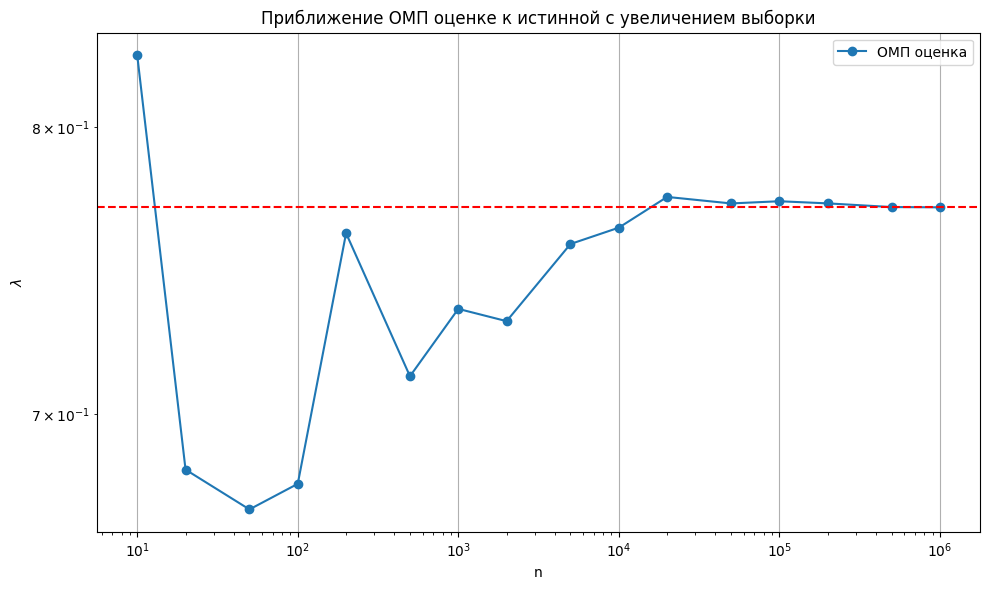

In [15]:
true_lambda = OMP(sample)

n_values = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000, 200000, 500000, df.shape[0]]
OMP_estimates = []

for n in n_values:
    n_sample = df["Выборка"].tolist()[:n]
    OMP_estimates.append(OMP(n_sample))

plt.figure(figsize=(10,6))
plt.loglog(n_values, OMP_estimates, marker="o", label="ОМП оценка")
plt.axhline(true_lambda, linestyle="--", color="red")
plt.title("Приближение ОМП оценке к истинной с увеличением выборки")
plt.xlabel("n")
plt.ylabel(r"$\lambda$")

plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


In [16]:
epsilon = 0.05
probabilities = []

for n in n_values:
    count = 0
    trials = 200  # сколько случайных подвыборок
    
    for _ in range(trials):
        subsample = np.random.choice(sample, size=n, replace=False)
        lambda_hat = OMP(subsample)
        
        if abs(lambda_hat - true_lambda) < epsilon:
            count += 1
    
    probabilities.append(count / trials)

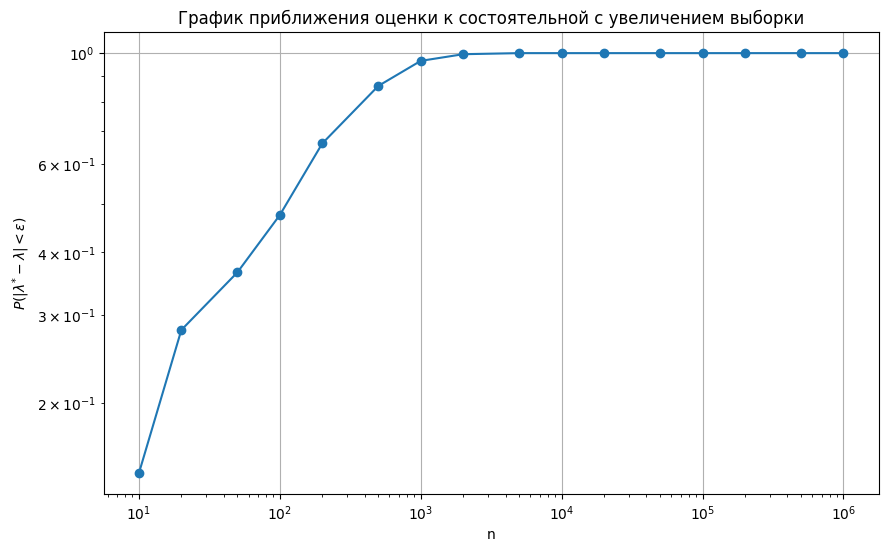

In [17]:
plt.figure(figsize=(10,6))
plt.loglog(n_values, probabilities, marker="o")

plt.xlabel("n")
plt.ylabel(r"$P(|\lambda^{*} - \lambda| < \varepsilon)$")
plt.title("График приближения оценки к состоятельной с увеличением выборки")
plt.grid()
plt.show()

#### Асимптотическая нормальность оценки

Говорим, что оценка $\lambda^{*}$ - $асимптотически \ нормальная \ оценка$ параметра $\lambda$ с коэффициентом $\sigma^{2}(\lambda)$, если $\forall \lambda \in \Lambda$ имеет место слабая сходимость при $n \rightarrow \infty$, т.е. $$\sqrt{n}(\lambda^{*} - \lambda) \xrightarrow[n \rightarrow \infty]{d} \mathcal{N}_{0, \sigma^{2}(\lambda)} \equiv \sqrt{n}\frac{\lambda^{*} - \lambda}{\sigma(\lambda)} \xrightarrow[n \rightarrow \infty]{d} \mathcal{N}_{0,1}$$ 

Положим нашу $\lambda^{*}$ за истинную (все таки она, как минимум, у нас состоятельная) и будем генерировать выборки с этой самой $\lambda$. Для каждой из выборок будем вычислять $\hat{\lambda}$. Ожидаем, что в конечном итоге $\sqrt{n}(\hat{\lambda} - {\lambda^{*}}) \xrightarrow{d} \mathcal{N}_{0, \sigma^{2}(\lambda^{*})}$ с увеличением выборки. (Нормируем и будем ожидать сходимости к стандартному нормальному, как в следующем абзаце).  

Проверять будем с помощью наложения плотности нормального распределения на гистограмму $\frac{\sqrt{n}(\hat{\lambda} - {\lambda^{*}})}{\lambda}$.  Так же воспользуемся графиком probplot, который сравнивает квантили двух распределений.

In [18]:
from scipy.stats import norm, probplot, gaussian_kde

def asymptotic_normality_plot(lambda_ref, n, n_sim=5000):
    z_values = []

    for _ in range(n_sim):
        sim_sample = np.random.exponential(scale=1 / lambda_ref, size=n)
        lambda_hat = OMP(sim_sample) #получаем какую-то оценку из множества оценок,
        #так как выборка сгенерирована случайно

        z = np.sqrt(n) * (lambda_hat - lambda_ref) / lambda_ref
        z_values.append(z) #к чему-то мы там сошлись

    z_values = np.array(z_values) #и построим из этого гистограмму
    x = np.linspace(z_values.min(), z_values.max(), 500)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.hist(z_values, bins=40, density=True, alpha=0.5, label="Гистограмма")

    kde = gaussian_kde(z_values)
    plt.plot(x, kde(x), linewidth=2, color="navy", label="KDE")

    plt.plot(
        x,
        norm.pdf(x, loc=0, scale=1),
        linestyle="--",
        color="red",
        label=r"$\mathcal{N}(0,1)$"
    )

    plt.title(f"Распределение нормированной ошибки, n={n}")
    plt.xlabel(r"$\sqrt{n}(\hat{\lambda}-\lambda^*)/\lambda^*$")
    plt.ylabel("Плотность")
    plt.grid(alpha=0.3)
    plt.legend()

    plt.subplot(1, 2, 2)
    probplot(z_values, dist="norm", plot=plt)
    plt.title(f"QQ-plot, n={n}")
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

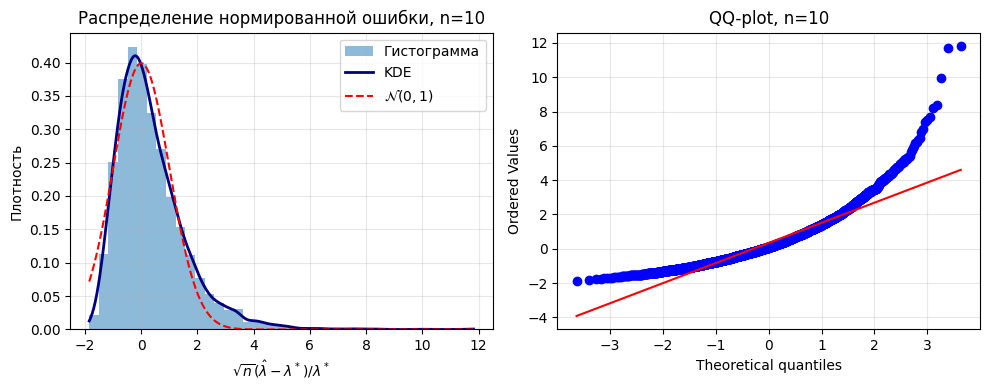

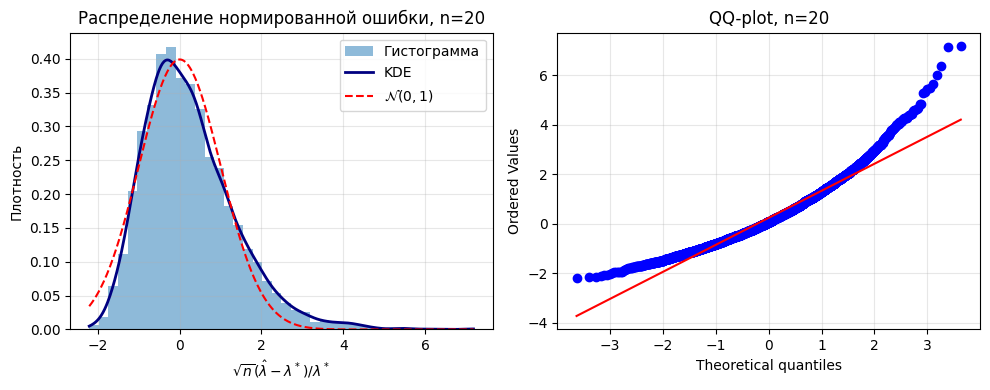

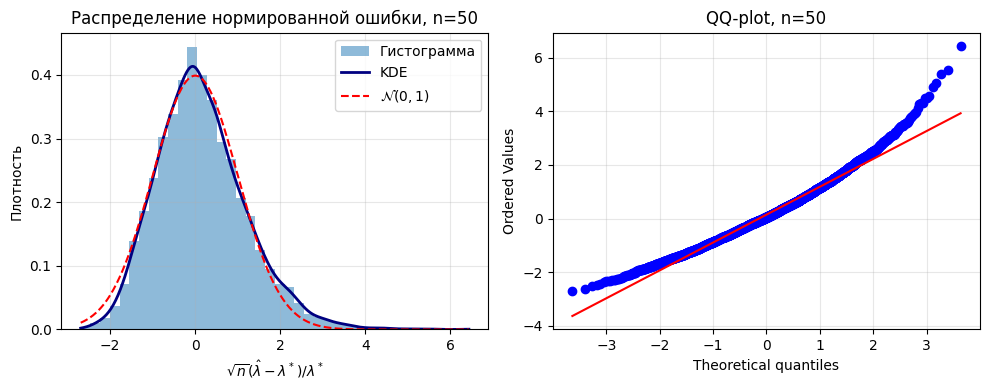

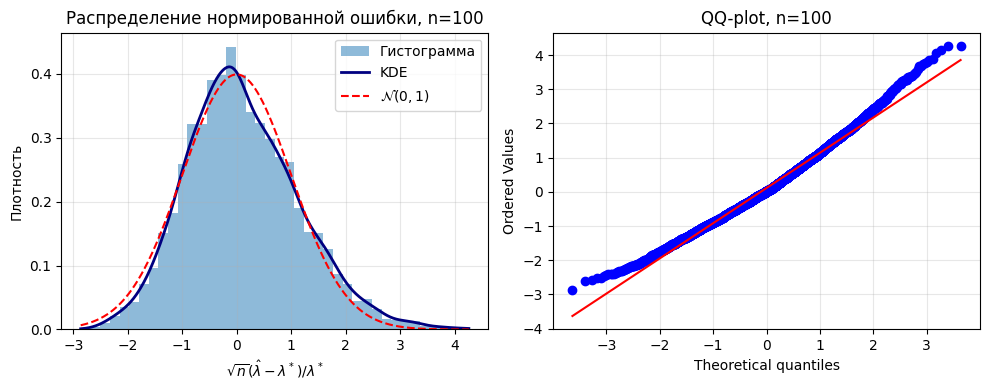

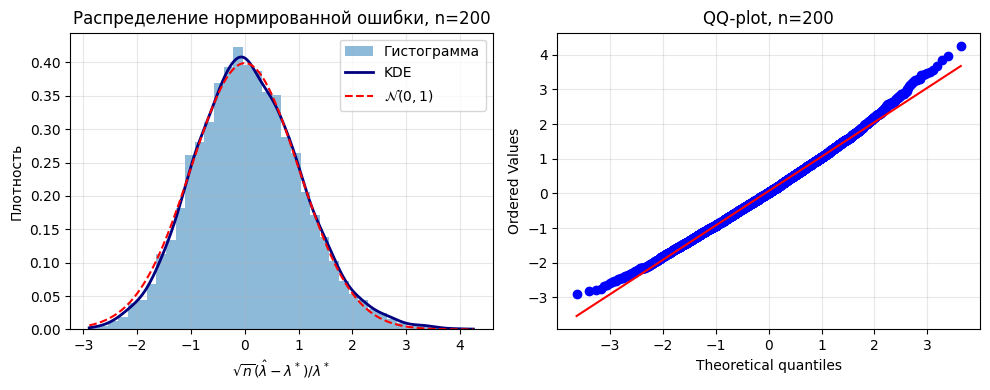

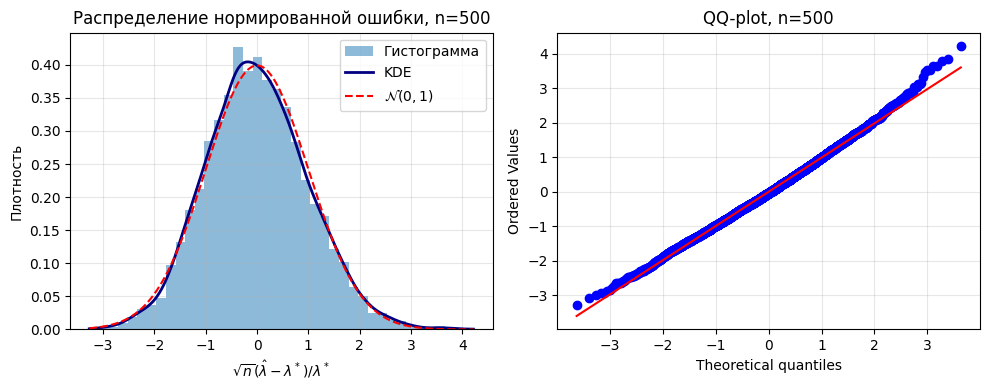

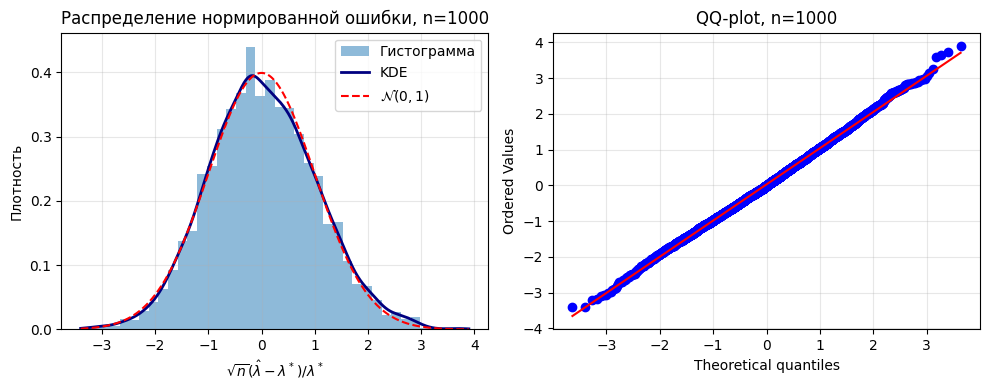

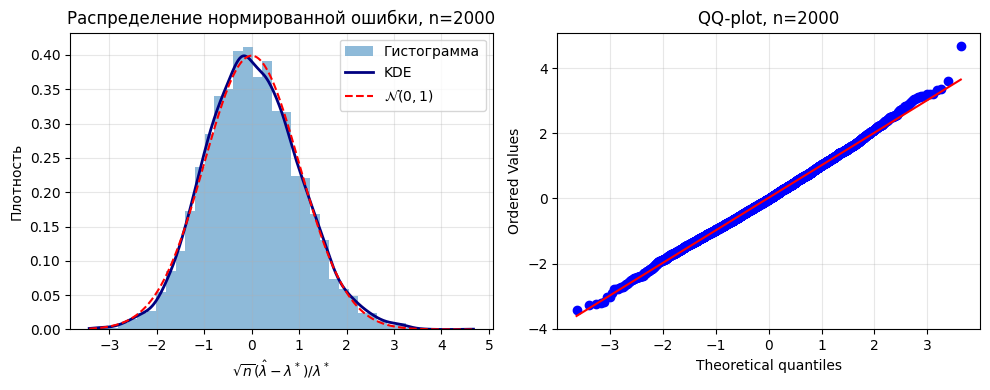

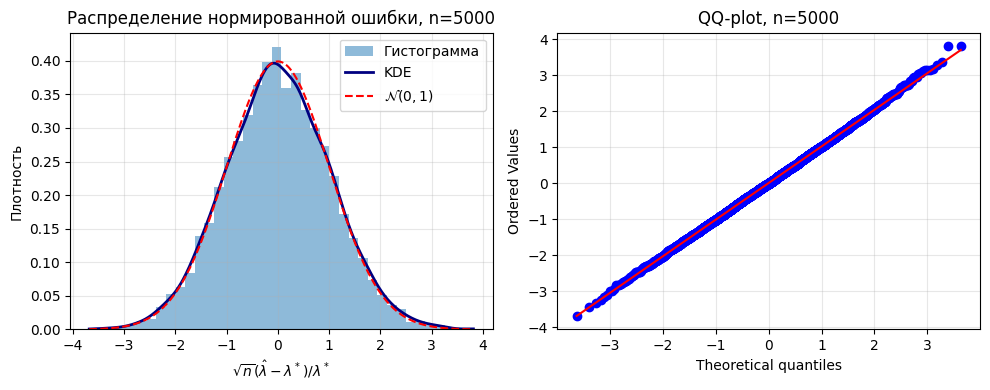

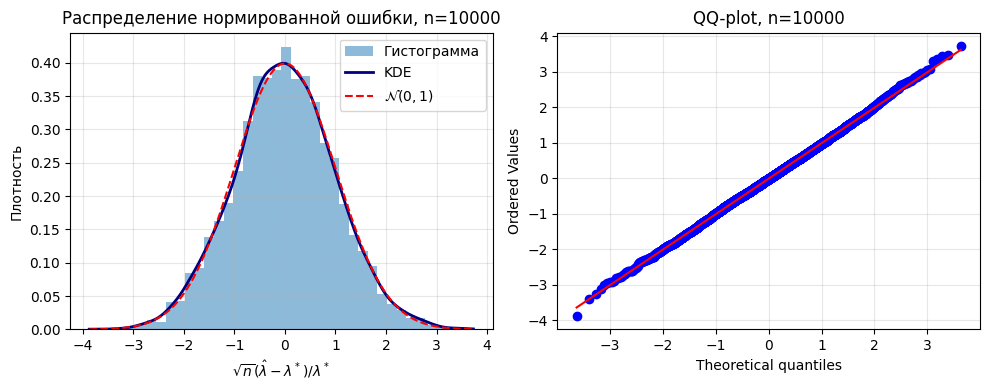

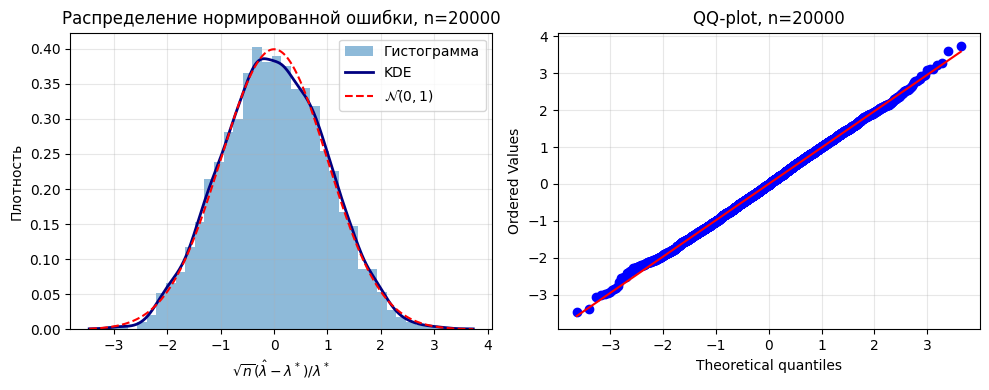

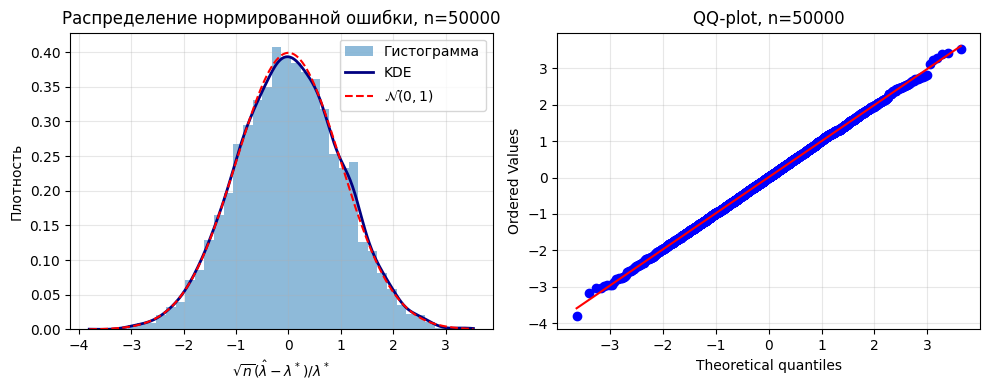

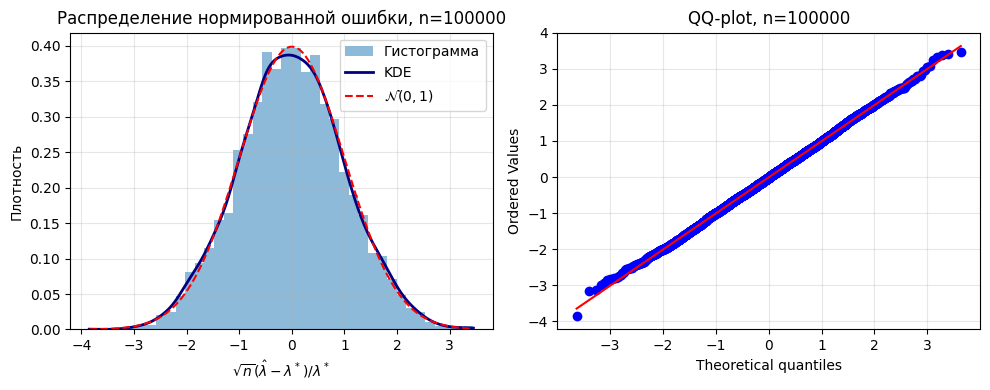

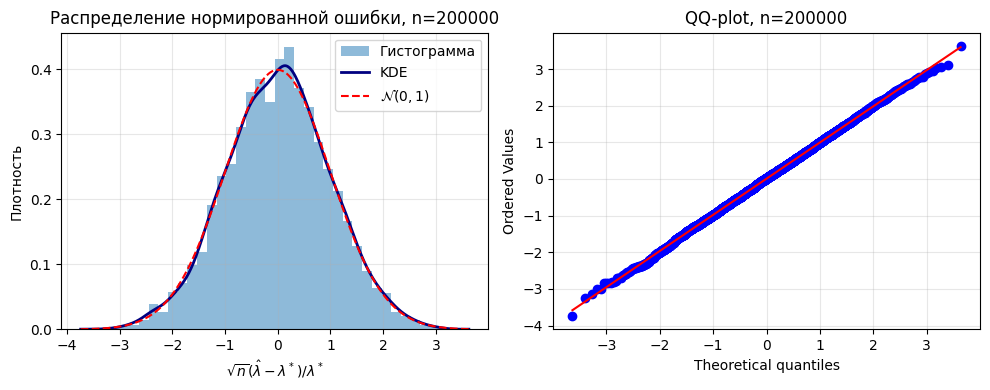

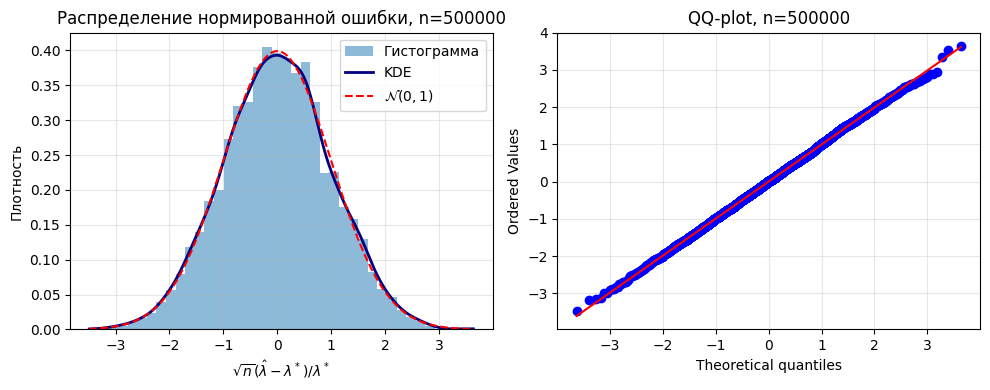

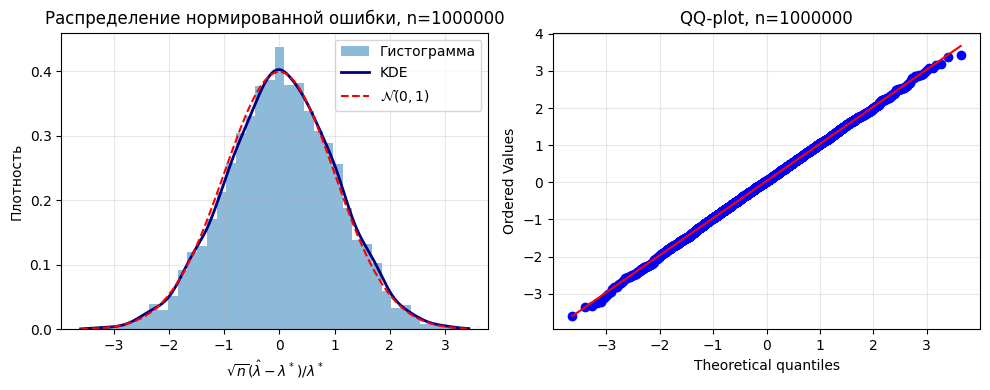

In [19]:
for n in n_values:
    asymptotic_normality_plot(true_lambda, n)

Видим, что с увеличем размера выборки $n$ распределение и плотность приближаются к нормальному $\Longrightarrow$ полагаем оценку асимптотически нормальной.

### Построить асимптотические доверительные интервалы уровней доверия $0.95$ и $0.99$

Итак, мы имеем $\vec{X} = (X_1, ... , X_n)$ - выборка объема $n$ из распределения $E_{\lambda \approx 0,77}$.  

Пусть $0 < \varepsilon < 1$. Интервал со случайными концами ($\lambda^{-}, \lambda^{+}$) = ($\lambda^{-}(\vec{X}, \varepsilon), \lambda^{+}(\vec{X}, \varepsilon)$) - **доверительный интервал** для параметра $\lambda$ с **уровнем доверия** $1 - \varepsilon$, если $$\forall \lambda \in \Lambda \ \ \ \mathbb{P}(\lambda^{-} < \lambda < \lambda^{+}) \geq 1 - \varepsilon$$


Соответственно говоря про асимптотиеский доверительный интервал уровня $0.95$ мы имеем в виду, что взял 100 разных выборок и построив для каждой из них интервал, в 95 из них будет $\lambda$, а в 5 - нет.

Итак, что мы имеем?  
$$\mathbb{E}(X) = \frac{1}{\lambda}, \mathbb{D}(X) \frac{1}{\lambda^2}$$

$$\lambda^{*} = \frac{1}{\overline{X}}$$

По Центральной Предельной Теореме:  
$$\sqrt{n}(\overline{X} - \mathbb{E}(X)) \xrightarrow{d} \mathcal{N}(0, \sigma^2(X)) \Longrightarrow \sqrt{n}(\overline{X} - \frac{1}{\lambda}) \xrightarrow{d} \mathcal{N}(0, \frac{1}{\lambda^2}) \Longrightarrow$$

$$\Longrightarrow \sqrt{n}\frac{\overline{X} - \frac{1}{\lambda}}{\frac{1}{\lambda}} \xrightarrow{d} \mathcal{N}(0,1) \Longrightarrow \frac{\overline{X} - \frac{1}{\lambda}}{\frac{1}{\lambda}} = \lambda \overline{X} - 1 \Longrightarrow \sqrt{n}(\lambda \overline{X} - 1) \xrightarrow{d} \mathcal{N}(0,1)$$

Так как $$\mathbb{P}(-z_{1 - \frac{\varepsilon}{2}} < Z < z_{1 - \frac{\varepsilon}{2}}) = 1 - \varepsilon, Z \sim \mathcal{N}(0,1) \Longrightarrow$$

$$\Longrightarrow \mathbb{P}(-z_{1 - \frac{\varepsilon}{2}} < \sqrt{n}(\lambda \overline{X} - 1) < z_{1 - \frac{\varepsilon}{2}}) \approx 1 - \varepsilon$$

Тогда $$-z < \sqrt{n}(\lambda \overline{X} - 1) < z \Longrightarrow -\frac{z}{\sqrt{n}} < \lambda \overline{X} - 1 < \frac{z}{\sqrt{n}} \Longrightarrow 1 - \frac{z}{\sqrt{n}} < \lambda \overline{X} < 1 + \frac{z}{\sqrt{n}} \Longrightarrow$$
$$\Longrightarrow \frac{1 - \frac{z}{\sqrt{n}}}{\overline{X}} < \lambda < \frac{1 + \frac{z}{\sqrt{n}}}{\overline{X}} \Longrightarrow$$
$$\Longrightarrow
\left(
\frac{1 - \frac{z_{1-\varepsilon/2}}{\sqrt{n}}}{\overline{X}},
\;
\frac{1 + \frac{z_{1-\varepsilon/2}}{\sqrt{n}}}{\overline{X}}
\right)
$$

Так как $$\lambda^{*} = \frac{1}{\overline{X}} \Longrightarrow$$
$$\Longrightarrow
\left(
\lambda^{*}\left(1 - \frac{z_{1-\varepsilon/2}}{\sqrt{n}}\right),
\;
{\lambda^{*}}\left(1 + \frac{z_{1-\varepsilon/2}}{\sqrt{n}}\right)
\right)
$$

In [22]:
def asymptotic_ci_lambda(sample, gamma=0.95):
    sample = np.asarray(sample, dtype=float)
    
    n = len(sample)
    x_bar = sample.mean()
    lambda_hat = 1 / x_bar
    
    alpha = 1 - gamma
    z = norm.ppf(1 - alpha / 2)
    
    left = lambda_hat * (1 - z / np.sqrt(n))
    right = lambda_hat * (1 + z / np.sqrt(n))
    
    return lambda_hat, left, right


In [ ]:

lambda_hat, l95, r95 = asymptotic_ci_lambda(sample, gamma=0.95)
temp, l99, r99 = asymptotic_ci_lambda(sample, gamma=0.99)

print(f"λ = {lambda_hat:.6f}")
print(f"95% ДИ: ({l95:.6f}, {r95:.6f})")
print(f"99% ДИ: ({l99:.6f}, {r99:.6f})")


λ = 0.770657
95% ДИ: (0.769146, 0.772167)
99% ДИ: (0.768672, 0.772642)


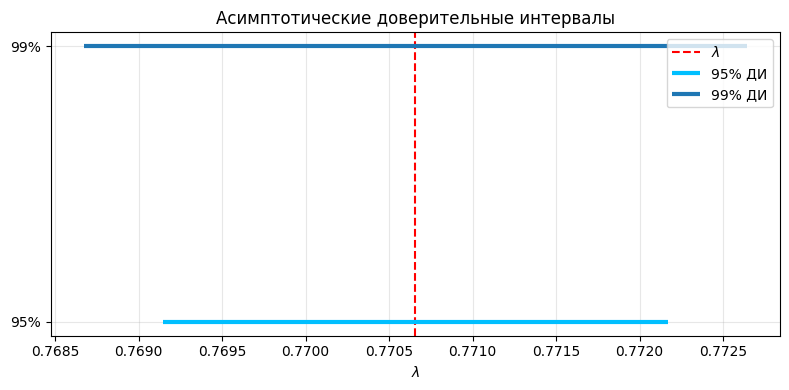

In [42]:
plt.figure(figsize=(8, 4))

plt.axvline(lambda_hat, linestyle="--", label=r"$\lambda$", color="red")

plt.hlines(y=1, xmin=l95, xmax=r95, linewidth=3, label="95% ДИ", color="deepskyblue")
plt.hlines(y=2, xmin=l99, xmax=r99, linewidth=3, label="99% ДИ")

plt.yticks([1, 2], ["95%", "99%"])
plt.xlabel(r"$\lambda$")
plt.title("Асимптотические доверительные интервалы")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Построили два наших доверительных интервала.

### Проверитить гипотезу о том, что выборка взята из угаданного распределения с оцененными параметрами. (Использовать критерий Колмогорова)

Имея выборку, мы можем выдвинуть несколько взаимоисключающих гипотез о теоретическом распределении, одну из которых следует предпочесть остальным. Задача выбора одной из нескольких гипотез решается построением статистического критерия.  

$Гипотезой \ (H)$ называется любое предположение о распределении наблюдений.  

$Критерием \ \delta = \delta(X_1,...X_n)$ называется измеримое отображение $$\delta : \mathbb{R}^n \rightarrow \{H_1,...H_k\}$$

Работаем, опять же, с $\vec{X} = (X_1, ... , X_n)$ - выборка распределения $E$. Проверяем **основную гипотезу** $H_1 = \{E = E_{\lambda^{*}}\}$ при **альтернативе** $H_2 = \{E \neq E_{\lambda^{*}}\}$  

Критерий Колмогорова рассматривается как критерий согласия для проверки гипотезы о распределении. Сравним эмпирическую функцию распределения $F^{*}_n(x)$ с теоретической функцией распределения $E_{\lambda^{*}}$. В качестве меры расхождения будем использовать статистику: $$\rho(\vec{X}) = \sqrt{n}\sup_{x}|F^{*}_n(x) - E_{\lambda^{*}}(x)|$$

In [64]:
from scipy.stats import kstest
from statsmodels.distributions.empirical_distribution import ECDF

sample_np = np.asarray(sample, dtype=float)

lambda_hat = OMP(sample_np) 

D, p_value = kstest(
    sample_np,
    cdf="expon",
    args=(0, 1 / lambda_hat)   #loc = 0, scale = 1/lambda_hat
)

print(f"lambda_hat = {lambda_hat:.6f}")
print(f"D = {D:.6f}")
print(f"p-value = {p_value:.6f}")

lambda_hat = 0.770657
D = 0.000731
p-value = 0.658181


По критерию Колмогорова получены значения статистики $D \approx 0.0007$ и $p-value \approx 0.66$ $\Longrightarrow$ нет оснований отвергать гипотезу о том, что выборка получена из экспоненциального распределения с параметром $\lambda^{*}$

Тем не менее следует отметить, что критерий Колмогорова рассматривается для гипотезы с заранее заданной функцией распределения. В нашем же случае параметр $\lambda^{*}$ был предварительно оценен нами же по той же самой выборке, по которой мы построили эмпирическую функцию распределения.   

В общем корректность наших действий, а так же валидность наших выводов вызывают у меня большие сомнения.  

### Понять, почему делать так, как в 5 пункте, нельзя.

